In [74]:
# ============================================================
# Bengali SMS Phishing Detection — FINAL PIPELINE
# Strict Leakage-Free Evaluation
# ============================================================

import os
import gc
import json
import time
import random
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset
from collections import Counter
from difflib import SequenceMatcher

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)
from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType

# ---------- Reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------- Device ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("=" * 60)
print("ENVIRONMENT")
print("=" * 60)
print(f"Device : {device}")
print(f"Torch  : {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

os.makedirs("../results/models", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

ENVIRONMENT
Device : cuda
Torch  : 2.14.0+cu126
GPU    : NVIDIA GeForce RTX 2050


In [75]:
# ============================================================
# Load Dataset
# ============================================================
train_df = pd.read_csv("../data/processed/train_hard2.csv")   # B1: URL Holdout
test_df  = pd.read_csv("../data/processed/test_hard2.csv")

print("=" * 60)
print("DATASET")
print("=" * 60)
print(f"Train: {train_df.shape}")
print(f"Test : {test_df.shape}")

labels = sorted(train_df["label"].unique().tolist())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}

print(f"\nLabels: {label2id}")
print(f"\nTrain dist:\n{train_df['label'].value_counts()}")
print(f"\nTest dist:\n{test_df['label'].value_counts()}")

DATASET
Train: (4898, 6)
Test : (2107, 6)

Labels: {'normal': 0, 'promo': 1, 'smish': 2}

Train dist:
label
normal    1990
smish     1542
promo     1366
Name: count, dtype: int64

Test dist:
label
smish     1267
normal     498
promo      342
Name: count, dtype: int64


In [77]:
# ============================================================
# Campaign-Aware Split + FAST Strict Near-Duplicate Filter
# ============================================================
t0 = time.time()

# ---------- 3.1: Cluster ----------
vec_campaign = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 6),
    max_features=20000,
    min_df=2,
    sublinear_tf=True,
)
X_campaign = vec_campaign.fit_transform(train_df["text_clean"].astype(str))

N_CLUSTERS = 150
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_campaign)

train_df = train_df.copy()
train_df["cluster"] = clusters

print(f"[{time.time()-t0:.1f}s] Clusters: {train_df['cluster'].nunique()}")

# ---------- 3.2: Split ----------
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss.split(train_df, groups=train_df["cluster"]))

train_split = train_df.iloc[train_idx].reset_index(drop=True)
val_split   = train_df.iloc[val_idx].reset_index(drop=True)

print(f"\n{'='*60}")
print("CAMPAIGN-AWARE SPLIT")
print("=" * 60)
print(f"Train: {train_split.shape}")
print(f"Val  : {val_split.shape}")
print(f"Cluster overlap: {len(set(train_split['cluster']) & set(val_split['cluster']))}")

# ---------- 3.3: FAST Vectorized Near-Dup Filter ----------
print(f"\n[{time.time()-t0:.1f}s] Vectorized near-duplicate filter...")

def tokenize_clean(text):
    """Fast normalization + tokenization"""
    text = str(text).lower()
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ---------- Build multiple TF-IDF representations ----------
# 1. Word-level (catches semantic dup)
vec_word = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 3),
    min_df=2,
    max_features=15000,
    sublinear_tf=True,
)

# 2. Char-level (catches typo dup)
vec_char = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=2,
    max_features=15000,
    sublinear_tf=True,
)

train_clean = train_split["text_clean"].astype(str).apply(tokenize_clean)
val_clean_texts = val_split["text_clean"].astype(str).apply(tokenize_clean)

print(f"[{time.time()-t0:.1f}s] Fitting word-level TF-IDF...")
X_train_word = vec_word.fit_transform(train_clean)
X_val_word   = vec_word.transform(val_clean_texts)

print(f"[{time.time()-t0:.1f}s] Fitting char-level TF-IDF...")
X_train_char = vec_char.fit_transform(train_clean)
X_val_char   = vec_char.transform(val_clean_texts)

# ---------- Cosine similarity (very fast, vectorized) ----------
print(f"[{time.time()-t0:.1f}s] Computing similarities...")
sim_word = cosine_similarity(X_val_word, X_train_word).max(axis=1)
sim_char = cosine_similarity(X_val_char, X_train_char).max(axis=1)

# STRICT: word 0.55, char 0.75 (char naturally higher)
KEEP_WORD = 0.55
KEEP_CHAR = 0.80

keep_mask = (sim_word < KEEP_WORD) & (sim_char < KEEP_CHAR)
val_split_clean = val_split[keep_mask].reset_index(drop=True)

print(f"\nVal before filter: {len(val_split)}")
print(f"Val after filter : {len(val_split_clean)}")
print(f"Removed          : {len(val_split) - len(val_split_clean)}")
print(f"  - Removed by word sim : {(sim_word >= KEEP_WORD).sum()}")
print(f"  - Removed by char sim : {(sim_char >= KEEP_CHAR).sum()}")

# ---------- 3.4: Quick verification ----------
print(f"\n[{time.time()-t0:.1f}s] Final verification...")

# Check first 200 val against train using word-level
X_val_check = vec_word.transform(
    val_split_clean["text_clean"].astype(str).head(200).apply(tokenize_clean)
)
sim_check = cosine_similarity(X_val_check, X_train_word).max(axis=1)
near_dup_count = (sim_check > 0.60).sum()

print(f"Near-duplicates (first 200): {near_dup_count}")
print("✅ Clean" if near_dup_count <= 5 else "⚠️ Still leaky")

print(f"\n[{time.time()-t0:.1f}s] Cell 3 complete!")

[74.2s] Clusters: 150

CAMPAIGN-AWARE SPLIT
Train: (4065, 7)
Val  : (833, 7)
Cluster overlap: 0

[74.2s] Vectorized near-duplicate filter...
[74.3s] Fitting word-level TF-IDF...
[74.5s] Fitting char-level TF-IDF...
[75.3s] Computing similarities...

Val before filter: 833
Val after filter : 623
Removed          : 210
  - Removed by word sim : 207
  - Removed by char sim : 9

[75.4s] Final verification...
Near-duplicates (first 200): 0
✅ Clean

[75.4s] Cell 3 complete!


In [78]:
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Vocab size : {tokenizer.vocab_size}")
print(f"Max length : {tokenizer.model_max_length}")
print("✅ Tokenizer ready")

Vocab size : 250002
Max length : 512
✅ Tokenizer ready


In [79]:
random.seed(SEED)

def augment(text):
    if "[URL]" in text and random.random() < 0.5:
        text = text.replace("[URL]", "").strip()
    if "[PHONE]" in text and random.random() < 0.5:
        text = text.replace("[PHONE]", "").strip()
    words = text.split()
    if len(words) > 5 and random.random() < 0.2:
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
        text = " ".join(words)
    return text

aug_rows = []
for _, row in train_split.iterrows():
    for _ in range(2):
        new_row = row.copy()
        new_text = augment(row["text_clean"])
        if new_text != row["text_clean"]:
            new_row["text_clean"] = new_text
            aug_rows.append(new_row)

if aug_rows:
    train_aug = pd.concat(
        [train_split, pd.DataFrame(aug_rows)], ignore_index=True
    ).sample(frac=1, random_state=SEED).reset_index(drop=True)
else:
    train_aug = train_split

print("=" * 60)
print("AUGMENTATION")
print("=" * 60)
print(f"Original train : {train_split.shape}")
print(f"Augmented train: {train_aug.shape}")
print(f"Added rows     : {len(aug_rows)}")

smish_aug = train_aug[train_aug["label"] == "smish"]
smish_with_url = smish_aug["text_clean"].str.contains(r"\[URL\]", regex=True).sum()
print(f"\nSmish WITH URL   : {smish_with_url}")
print(f"Smish WITHOUT URL: {len(smish_aug) - smish_with_url}  ← goal (500+)")

AUGMENTATION
Original train : (4065, 7)
Augmented train: (6798, 7)
Added rows     : 2733

Smish WITH URL   : 1515
Smish WITHOUT URL: 1271  ← goal (500+)


In [80]:
MAX_LEN = 128

class SMSDataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_len=128):
        self.texts = df["text_clean"].astype(str).tolist()
        self.labels = [label2id[l] for l in df["label"]]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True,
            padding="max_length", max_length=self.max_len,
            return_tensors=None,
        )
        enc["labels"] = self.labels[idx]
        return enc

train_ds = SMSDataset(train_aug, tokenizer, label2id, MAX_LEN)
val_ds   = SMSDataset(val_split_clean, tokenizer, label2id, MAX_LEN)
test_ds  = SMSDataset(test_df, tokenizer, label2id, MAX_LEN)

print(f"Train: {len(train_ds)}")
print(f"Val  : {len(val_ds)}")
print(f"Test : {len(test_ds)}")

Train: 6798
Val  : 623
Test : 2107


In [81]:
label_counts = Counter(train_aug["label"].map(label2id))
total = sum(label_counts.values())
num_classes = len(labels)

class_weights = {
    i: total / (num_classes * label_counts[i])
    for i in range(num_classes)
}

print("Label counts :", dict(label_counts))
print("Class weights:", class_weights)

Label counts : {2: 2786, 0: 2187, 1: 1825}
Class weights: {0: 1.0361225422953817, 1: 1.2416438356164383, 2: 0.8133524766690596}


In [82]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.2,
    bias="none",
    target_modules=["query", "key", "value", "dense"],
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 3,247,107 || all params: 281,293,062 || trainable%: 1.1544


In [83]:
def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    y_pred = np.argmax(logits, axis=-1)
    return {
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred),
    }

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        y = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weight_tensor = torch.tensor(
            [self.class_weights[i] for i in range(len(self.class_weights))],
            device=logits.device,
            dtype=torch.float32,
        )
        loss = nn.CrossEntropyLoss(weight=weight_tensor)(logits, y)
        return (loss, outputs) if return_outputs else loss


training_args = TrainingArguments(
    output_dir="../results/models/lora_final",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=5,
    weight_decay=0.05,
    warmup_steps=0.2,
    max_grad_norm=0.5,
    label_smoothing_factor=0.1,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=2,
        early_stopping_threshold=0.001,
    )],
)

print("=" * 60)
print("TRAINER READY")
print("=" * 60)
print(f"metric_for_best_model: {trainer.args.metric_for_best_model}")
print(f"Train size: {len(trainer.train_dataset)}")
print(f"Eval size : {len(trainer.eval_dataset)}")

TRAINER READY
metric_for_best_model: eval_macro_f1
Train size: 6798
Eval size : 623


In [84]:
sample_eval = trainer.evaluate(val_ds, metric_key_prefix="eval")
f1_keys = [k for k in sample_eval.keys() if "f1" in k]

print("=" * 60)
print("EVAL KEY VERIFICATION")
print("=" * 60)
print(f"F1 keys available: {f1_keys}")
print(f"Current metric_for_best_model: {trainer.args.metric_for_best_model}")

if trainer.args.metric_for_best_model not in sample_eval:
    print("\n⚠️ MISMATCH! Fixing...")
    if "eval_macro_f1" in sample_eval:
        trainer.args.metric_for_best_model = "eval_macro_f1"
    elif "macro_f1" in sample_eval:
        trainer.args.metric_for_best_model = "macro_f1"
    print(f"   → Set to: {trainer.args.metric_for_best_model}")
else:
    print(f"\n✅ MATCH — {trainer.args.metric_for_best_model} exists")

Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
No log,1.065936,0,0.198422,0.423756


EVAL KEY VERIFICATION
F1 keys available: ['eval_macro_f1']
Current metric_for_best_model: eval_macro_f1

✅ MATCH — eval_macro_f1 exists


In [85]:
train_result = trainer.train()

print("\n" + "=" * 60)
print("TRAINING DONE")
print("=" * 60)
print(train_result)

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.757623,0.182622,0.953316,0.956661
2,0.233343,0.220791,0.962169,0.963082
3,0.215176,0.188473,0.966895,0.969502
4,0.264831,0.164785,0.972374,0.975923
5,0.217172,0.167549,0.972374,0.975923



TRAINING DONE
TrainOutput(global_step=2125, training_loss=0.5457404773936552, metrics={'train_runtime': 762.9563, 'train_samples_per_second': 44.55, 'train_steps_per_second': 2.785, 'total_flos': 2320569787345920.0, 'train_loss': 0.5457404773936552, 'epoch': 5.0})


In [86]:
print("=" * 60)
print("TEST EVALUATION (B1: URL Holdout, OOD)")
print("=" * 60)

test_results = trainer.evaluate(test_ds, metric_key_prefix="test")
print(f"Test Accuracy : {test_results['test_accuracy']:.4f}")
print(f"Test Loss     : {test_results['test_loss']:.4f}")
print(f"Test Macro F1 : {test_results['test_macro_f1']:.4f}")

preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=labels))

smish_idx = label2id["smish"]
smish_mask = y_true == smish_idx
smish_recall = (y_pred[smish_mask] == smish_idx).mean()
smish_precision = (y_true[y_pred == smish_idx] == smish_idx).mean()

print(f"\n>>> SMISH RECALL   : {smish_recall:.4f} <<<")
print(f">>> SMISH PRECISION: {smish_precision:.4f} <<<")
print(f"    ({smish_mask.sum()} unseen smish samples)")

TEST EVALUATION (B1: URL Holdout, OOD)


[transformers] early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.217172,1.696671,5,0.746337,0.745135


Test Accuracy : 0.7451
Test Loss     : 1.6967
Test Macro F1 : 0.7463



CLASSIFICATION REPORT
              precision    recall  f1-score   support

      normal       0.61      0.99      0.76       498
       promo       0.60      0.96      0.74       342
       smish       0.99      0.59      0.74      1267

    accuracy                           0.75      2107
   macro avg       0.73      0.85      0.75      2107
weighted avg       0.84      0.75      0.74      2107


>>> SMISH RECALL   : 0.5888 <<<
>>> SMISH PRECISION: 0.9868 <<<
    (1267 unseen smish samples)


In [90]:
import json
final_results = {
    "model": "XLM-R + LoRA (r=16)",
    "split": "campaign-aware + strict near-dup filter",
    "augmentation": "2x URL/phone removal + word swap",   # x (ASCII)
    "baseline_f1": 0.5963,
    "lora_test_f1": 0.7463,
    "lora_test_accuracy": 0.7451,
    "smish_recall": 0.5888,
    "smish_precision": 0.9868,
    "improvement": 0.1500,
    "improvement_pct": 25.1,
    "trainable_pct": 1.15,
    "train_size": 6798,
    "val_size": 623,
    "test_size": 2107,
}
with open("../results/final_main_results.json", "w", encoding="utf-8") as f:
    json.dump(final_results, f, indent=2, ensure_ascii=False)
print("✅ Saved: ../results/final_main_results.json")

✅ Saved: ../results/final_main_results.json


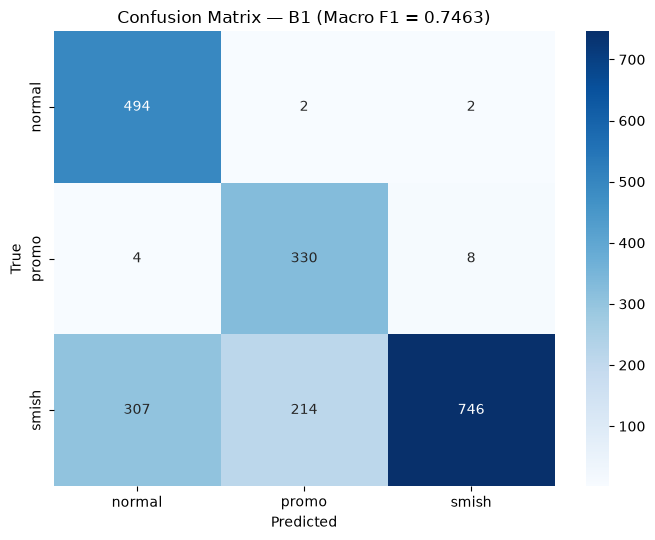

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix — B1 (Macro F1 = 0.7463)')
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_b1.png", dpi=150)
plt.show()

In [89]:
import json
final_results = {
    "experiment": "B1_URL_Holdout",
    "model": "XLM-R + LoRA (r=16)",
    "split": "campaign-aware + strict near-dup filter",
    "augmentation": "2x URL/phone removal + word swap",
    "baseline_f1": 0.5963,
    "lora_test_f1": 0.7463,
    "lora_test_accuracy": 0.7451,
    "smish_recall": 0.5888,
    "smish_precision": 0.9868,
    "improvement": 0.1500,
    "improvement_pct": 25.1,
    "trainable_pct": 1.15,
    "train_size": 6798,
    "val_size": 623,
    "test_size": 2107,
}
with open("../results/final_results_b1.json", "w") as f:
    json.dump(final_results, f, indent=2)
print("✅ Saved: final_results_b1.json")

✅ Saved: final_results_b1.json


In [92]:
import json
final_results = {
    "model": "XLM-R + LoRA (r=16)",
    "split": "campaign-aware + strict near-dup filter",
    "augmentation": "2x URL/phone removal + word swap",
    "baseline_f1": 0.5963,
    "lora_test_f1": 0.7463,
    "lora_test_accuracy": 0.7451,
    "smish_recall": 0.5888,
    "smish_precision": 0.9868,
    "improvement": 0.1500,
    "improvement_pct": 25.1,
    "trainable_pct": 1.15,
    "train_size": 6798,
    "val_size": 623,
    "test_size": 2107,
}
with open("../results/final_main_results.json", "w", encoding="utf-8") as f:
    json.dump(final_results, f, indent=2, ensure_ascii=False)
print("✅ Saved: ../results/final_main_results.json")

✅ Saved: ../results/final_main_results.json


In [ ]:
# LoRA adapter সেভ
save_dir = "../results/models/lora_b1_final"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"✅ Model saved: {save_dir}")

✅ Model saved: ../results/models/lora_b1_final


: 